In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

In [40]:
url = "https://raw.githubusercontent.com/sudhanshu456/Machine-Learning-with-Python-IBM/master/Week%202/Data_set/FuelConsumption.csv"
df = pd.read_csv(url)

print(df)

      MODELYEAR   MAKE  ... FUELCONSUMPTION_COMB_MPG CO2EMISSIONS
0          2014  ACURA  ...                       33          196
1          2014  ACURA  ...                       29          221
2          2014  ACURA  ...                       48          136
3          2014  ACURA  ...                       25          255
4          2014  ACURA  ...                       27          244
...         ...    ...  ...                      ...          ...
1062       2014  VOLVO  ...                       24          271
1063       2014  VOLVO  ...                       25          264
1064       2014  VOLVO  ...                       24          271
1065       2014  VOLVO  ...                       25          260
1066       2014  VOLVO  ...                       22          294

[1067 rows x 13 columns]


In [56]:
print("Clean 1")
print(df[["FUELCONSUMPTION_COMB","ENGINESIZE","CO2EMISSIONS"]].dtypes)
print()

for col in ["FUELCONSUMPTION_COMB","ENGINESIZE","CO2EMISSIONS"]:
    if df[col].dtype == 'object':
        print(f"{col} is text converting it to numeric....")
        df = pd.to_numeric(df[["FUELCONSUMPTION_COMB","ENGINESIZE","CO2EMISSIONS"]].dtype)
    else:
        print(f"{col} has numeric values")

Clean 1
FUELCONSUMPTION_COMB    float64
ENGINESIZE              float64
CO2EMISSIONS              int64
dtype: object

FUELCONSUMPTION_COMB has numeric values
ENGINESIZE has numeric values
CO2EMISSIONS has numeric values


In [60]:
print("Clean 2 Missng values")
missing = df[["FUELCONSUMPTION_COMB","ENGINESIZE","CO2EMISSIONS"]].isnull().sum()

for col, count in missing.items():
    if count == 0:
        print("No missing values")
    else:
        print(f"{col} Missing values found filling it with median")

df["ENGINESIZE"] = df["ENGINESIZE"].fillna(df[["ENGINESIZE"]].median())
df["FUELCONSUMPTION"] = df["FUELCONSUMPTION_COMB"].fillna(df["FUELCONSUMPTION_COMB"].median())
df["CO2EMISSION"] = df["CO2EMISSIONS"].fillna(df[["CO2EMISSIONS"]].median())

remaining = df[["FUELCONSUMPTION_COMB","ENGINESIZE","CO2EMISSIONS"]].isnull().sum().sum()
print(f"\n After fix total missing values {remaining}")

Clean 2 Missng values
No missing values
No missing values
No missing values

 After fix total missing values 0


In [61]:
print("Clean 3: Duplicats")
duplicats = df.duplicated().sum()

if duplicats == 0:
    print("No duplicats")
else:
    print("Duplicats found...cleaning..")
    df = df.drop_duplicated()
    print(f"Duplicates remove new shape is {df.shape}")

Clean 3: Duplicats
No duplicats


In [ ]:
print("Clean 4")
cols_to_check = df[["ENGINESIZE","FUELCONSUMPITON_COMB","CO2EMISSIONS"]]
total_outliers = 0

for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    higher_fence = Q3 + 1.5 * IQR

    outliers_mask = (df[col] < lower_fence | df[col] > high_fence)
    outliers_count = outliers_mask.sum()
    total_outliers += outliers_count

    if total_outliers == 0:
        print("NO extreem outliners found")
    else:
        

In [41]:
X = df[["FUELCONSUMPTION_COMB","ENGINESIZE"]].to_numpy()
Y = df[["CO2EMISSIONS"]].to_numpy()

In [42]:
scalar = preprocessing.StandardScaler()
X_scaled = scalar.fit_transform(X)

In [43]:
X_train,X_test,Y_train,Y_test = train_test_split(X_scaled,Y,test_size = 0.2,random_state = 42)

In [44]:
model = LinearRegression()
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
y_pred = model.predict(X_test)

r2 = r2_score(Y_test,y_pred)
mse = mean_squared_error(Y_test,y_pred)
rms = np.sqrt(mse)

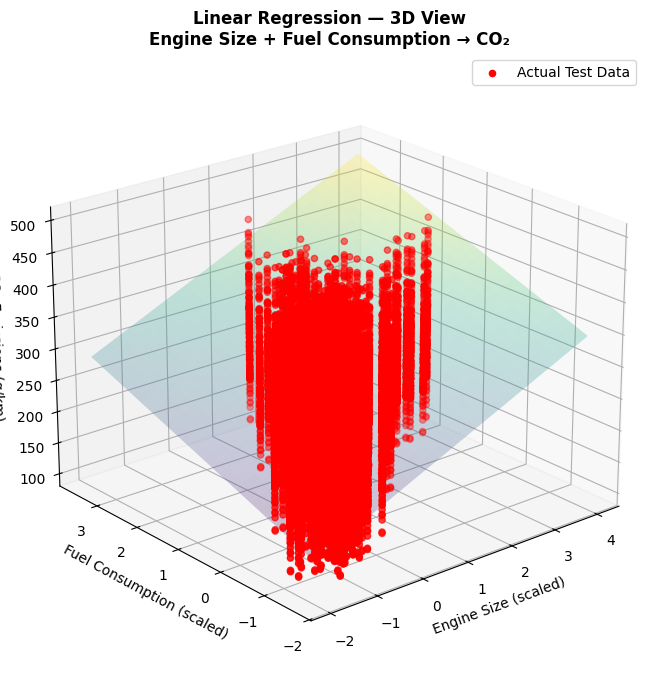

📊 Plot 1 saved → plot1_3d_regression.png


In [46]:
x0_min, x0_max = X_scaled[:, 0].min(), X_scaled[:, 0].max()
x1_min, x1_max = X_scaled[:, 1].min(), X_scaled[:, 1].max()
 
grid_x0, grid_x1 = np.meshgrid(
    np.linspace(x0_min, x0_max, 30),
    np.linspace(x1_min, x1_max, 30)
)
 
# Predict CO2 for every point on the grid
plane_z = model.predict(np.c_[grid_x0.ravel(), grid_x1.ravel()])
plane_z = plane_z.reshape(grid_x0.shape)
 
# Draw the 3D chart
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")
 
# Regression plane (semi-transparent surface)
ax.plot_surface(grid_x0, grid_x1, plane_z,
                cmap="viridis", alpha=0.25, linewidth=0)
 
# Actual test points
ax.scatter(X_test[:, 0], X_test[:, 1], Y_test,
           color="red", s=20, label="Actual Test Data")
 
ax.set_xlabel("Engine Size (scaled)")
ax.set_ylabel("Fuel Consumption (scaled)")
ax.set_zlabel("CO₂ Emissions (g/km)")
ax.set_title("Linear Regression — 3D View\nEngine Size + Fuel Consumption → CO₂",
             fontsize=12, fontweight="bold")
ax.view_init(elev=22, azim=-130)
plt.legend()
plt.tight_layout()
plt.savefig("plot1_3d_regression.png", dpi=150)
plt.show()
print("📊 Plot 1 saved → plot1_3d_regression.png")


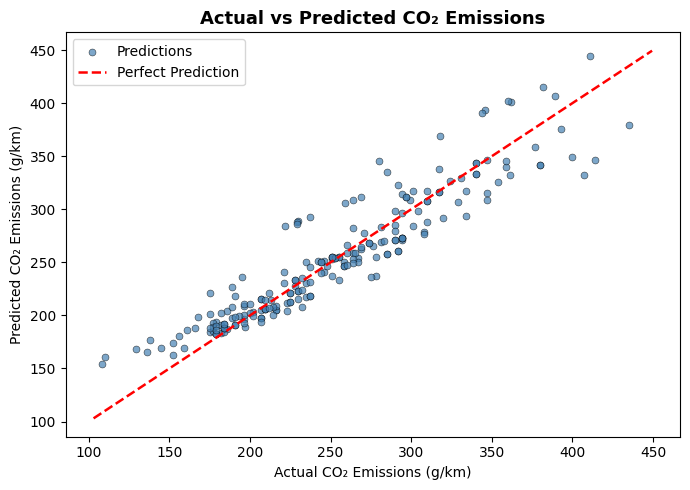

📊 Plot 2 saved → plot2_actual_vs_predicted.png


In [48]:
plt.figure(figsize=(7, 5))
 
plt.scatter(Y_test, y_pred, color="steelblue",
            edgecolors="k", linewidths=0.4, s=25, alpha=0.7, label="Predictions")
 
# Draw the perfect-prediction reference line
min_val = min(Y_test.min(), y_pred.min()) - 5
max_val = max(Y_test.max(), y_pred.max()) + 5
plt.plot([min_val, max_val], [min_val, max_val],
         "r--", linewidth=1.8, label="Perfect Prediction")
 
plt.xlabel("Actual CO₂ Emissions (g/km)")
plt.ylabel("Predicted CO₂ Emissions (g/km)")
plt.title("Actual vs Predicted CO₂ Emissions", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_actual_vs_predicted.png", dpi=150)
plt.show()
print("📊 Plot 2 saved → plot2_actual_vs_predicted.png")

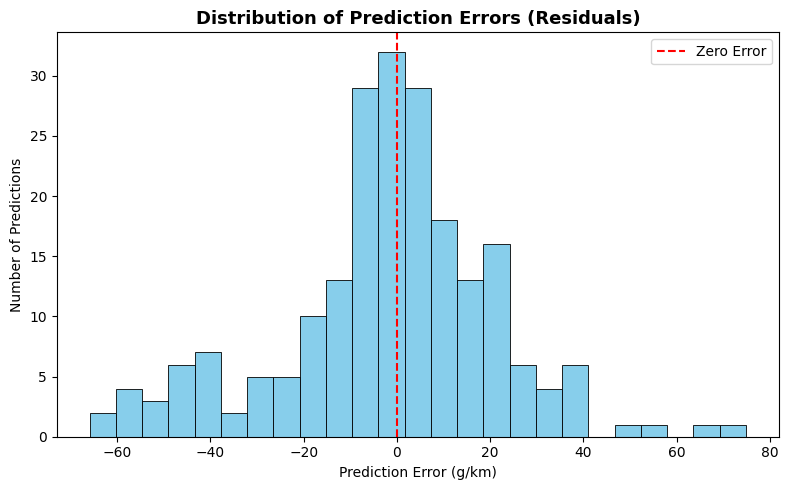

📊 Plot 3 saved → plot3_residuals.png

🎉 All done! Great job running your first regression model.


In [49]:
residuals = Y_test - y_pred
 
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25, color="skyblue", edgecolor="black", linewidth=0.6)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero Error")
plt.xlabel("Prediction Error (g/km)")
plt.ylabel("Number of Predictions")
plt.title("Distribution of Prediction Errors (Residuals)", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("plot3_residuals.png", dpi=150)
plt.show()
print("📊 Plot 3 saved → plot3_residuals.png")
 
print()
print("🎉 All done! Great job running your first regression model.")